Sistemas y señales discretos - Labortaorio Bioseñales
Estudiante: Luis Eduardo Grajales H. CC 1003293560
Estudiante: Valentina Garcia Obando CC1000539432

In [27]:
import numpy as np
import matplotlib.pyplot as plt

1. Implemente una función en Python que permita generar una función escalón unitario, definida en un intervalo 𝑛1≤𝑛0≤𝑛2

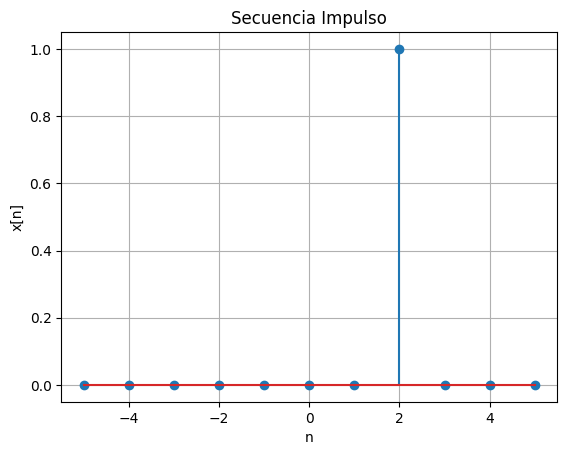

In [28]:
def impseq(n0, n1, n2):
    n = np.arange(n1, n2+1)
    x = ((n-n0) == 0).astype(int)
    return x, n

# ejemplo: impulso en n0=2 entre -5 y 5
x, n = impseq(2, -5, 5)

plt.stem(n, x)
plt.xlabel("n")
plt.ylabel("x[n]")
plt.title("Secuencia Impulso")
plt.grid(True)
plt.show()

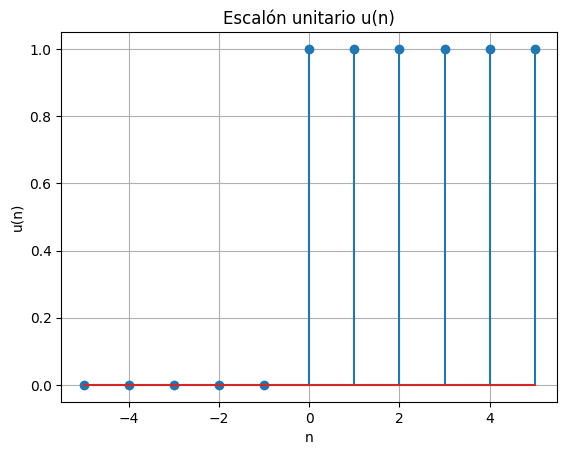

In [29]:
def unitario(n0, n1, n2):
# ----------------------------------------------
 n = np.arange(n1,n2+1) # Se crea el vector de muestras
 x = (n - n0) >= 0             # condicion para que sea 1 o True
 x = x.astype(int)             # convertir True/False -> 1/0
 return [x,n]

x, n = unitario(0, -5, 5)
plt.stem(n, x)
plt.title("Escalón unitario u(n)")
plt.xlabel("n")
plt.ylabel("u(n)")
plt.grid(True)


2. Implemente una función en Python que permita generar una función rampa, definida en un intervalo 𝑛1≤𝑛0≤𝑛2 con una pendiente m.

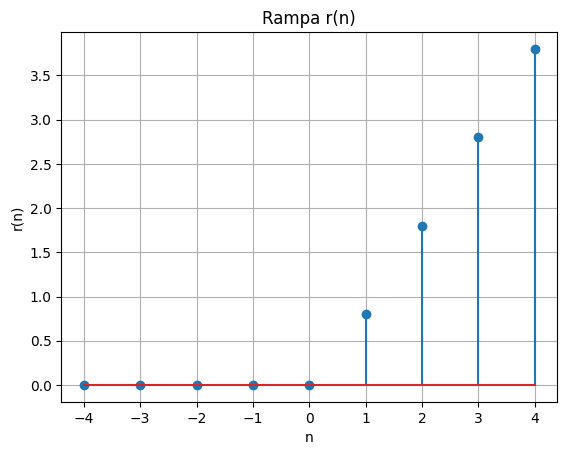

In [30]:
def rampa(n0, n1, n2):
# ----------------------------------------------
 n = np.arange(n1,n2+1) # Se crea el vector de muestras
 x = (n - n0) * (n >= n0)      # condicion para que sea 1 o True
 return [x,n]

#Ejemplo
x, n = rampa(0.2, -4, 4)
plt.stem(n, x)
plt.title("Rampa r(n)")
plt.xlabel("n")
plt.ylabel("r(n)")
plt.grid(True)
plt.show()

3. Genere las siguientes secuencias usando las funciones básicas de Python que se han presentado. Grafique los resultados.

a. 𝑥1(𝑛)= 3𝛿(𝑛+1)+5𝛿(𝑛+3)+3𝛿(𝑛+2)+3𝛿(𝑛)+ 𝛿(𝑛). ¿Cómo debe ser el vector de muestras?

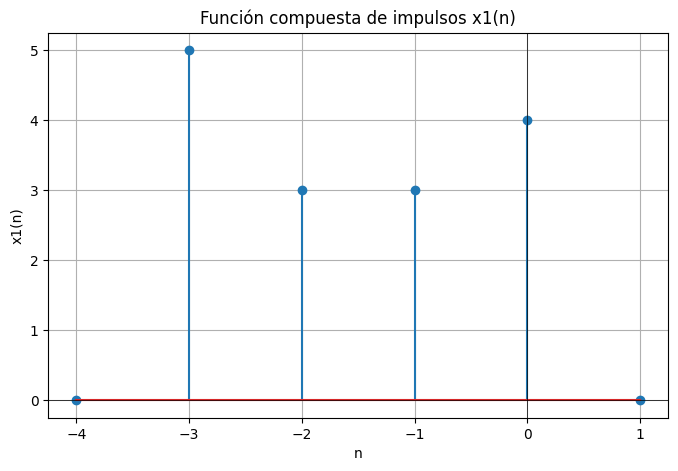

In [31]:
def impseq(n0, n1, n2):
# Genera x(n) = delta(n-n0); n1 <= n <= n2
# ----------------------------------------------
 n = np.arange(n1,n2+1) # Se crea el vector de muestras
 x = (n-n0) == 0
 return [x,n]

n1 = -4
n2 = 1

# Crear los impulsos con las amplitudes correspondientes
imp1, n = impseq(-1, n1, n2)  # 3δ(n + 1)
imp2, _ = impseq(-3, n1, n2)  # 5δ(n + 3)
imp3, _ = impseq(-2, n1, n2)  # 3δ(n + 2)
imp4, _ = impseq(0, n1, n2)   # 3δ(n) + δ(n)

# Crear la secuencia x1(n)
x1 = 3 * imp1 + 5 * imp2 + 3 * imp3 + 4 * imp4  # Sumar impulsos ponderados

# Graficar la función compuesta por impulsos
plt.figure(figsize=(8, 5))
plt.stem(n, x1)
plt.title('Función compuesta de impulsos x1(n)')
plt.xlabel('n')
plt.ylabel('x1(n)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

b. El siguiente sistema arroja una secuencia definida entre −6≤𝑛≤6

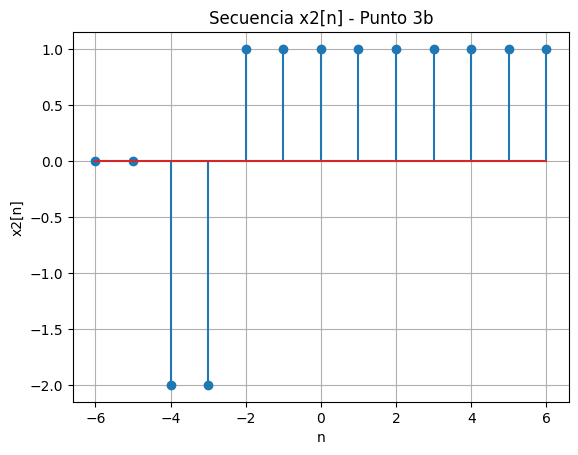

In [32]:
# Señales escalón
x1u, n = unitario(-4, -6, 6)   # u(n+4)
x2u, _ = unitario(-2, -6, 6)   # u(n+2)

# Señal final
x2 = -2*x1u + 3*x2u

# Gráfica
plt.stem(n, x2)
plt.title("Secuencia x2[n] - Punto 3b")
plt.xlabel("n")
plt.ylabel("x2[n]")
plt.grid(True)
plt.show()

c. El siguiente sistema arroja una secuencia definida entre 0≤𝑛≤100

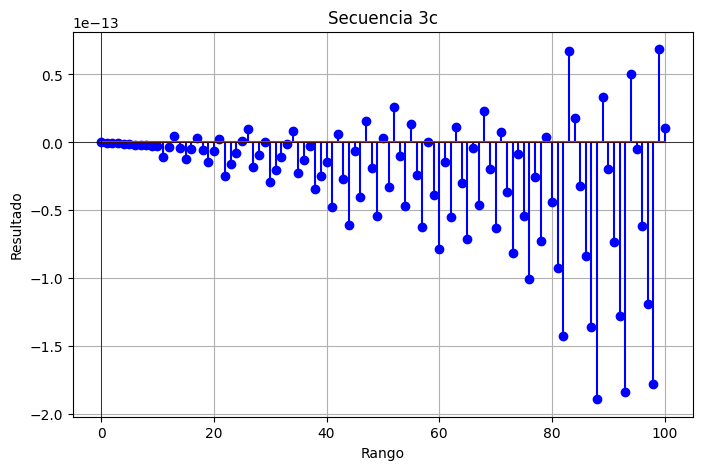

In [33]:
def expo(n, n1, n2):
  e = np.exp(0.01 * n)
  return e

def seno(n, n1, n2):
  s = np.sin(2 * np.pi *n )
  return s

n=np.arange(0,101)
n1 = 0
n2 = n[-1]

exponencial = expo(n, n1, n2)
sinusoidal = seno(n,n1,n2)

secuencia = exponencial * sinusoidal

plt.figure(figsize=(8, 5))
plt.stem(n,secuencia,'b')
plt.title('Secuencia 3c')
plt.xlabel('Rango')
plt.ylabel('Resultado')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid()
plt.show()

d. 𝑥4 (𝑛) = 2𝑟(𝑛 + 3) − 𝑟(𝑛 − 2) − 5𝑢(𝑛 − 3), −10 ≤ 𝑛 ≤ 10

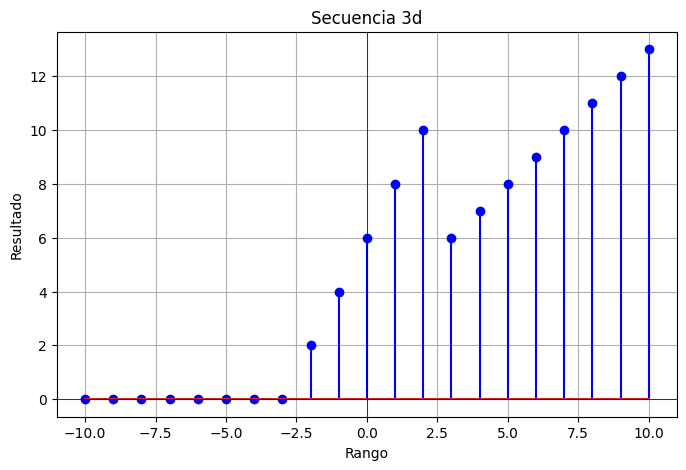

In [34]:
def unitario(n):
    u = np.where(n >= 0, 1, 0)
    return u

def rampa(n):
    r = np.maximum(n, 0)
    return r

n = np.arange(-10, 11)

x4 = 2 * rampa(n + 3) - rampa(n - 2) - 5 * unitario(n - 3)#se pasa la secuencia mostrada en la guía

plt.figure(figsize=(8, 5))
plt.stem(n, x4,'b')
plt.title('Secuencia 3d')
plt.xlabel('Rango')
plt.ylabel('Resultado')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid()
plt.show()

4. Genere la siguiente secuencia

𝑥[𝑛] = { 𝑟[𝑛] 0 ≤ 𝑛 ≤ 5

𝑟[𝑛 − 5] 6 ≤ 𝑛 ≤ 11

𝑟[𝑛 − 10] 12 ≤ 𝑛 ≤ 17}

a. Derive la secuencia

b. Realice un subplot con las dos secuencias, la original, y la derivada. Describa lo que observa y el porqué no es exactamente la derivada del caso continuo.

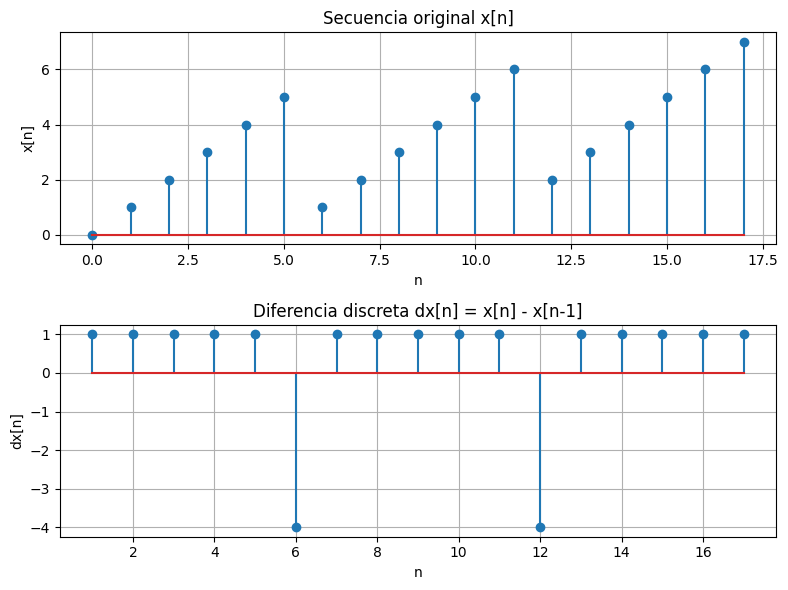

In [35]:
# -----------------------------------------
# Función rampa discreta
# r[n] = (n - n0) u[n - n0]
# -----------------------------------------
def rampa(n0, n1, n2):
    n = np.arange(n1, n2+1)
    x = (n - n0) * (n >= n0).astype(int)
    return x, n

# -----------------------------------------
# Generar los tres tramos
# -----------------------------------------
x1, n1 = rampa(0, 0, 5)       # r[n]
x2, n2 = rampa(5, 6, 11)      # r[n-5]
x3, n3 = rampa(10, 12, 17)    # r[n-10]

# Concatenar todo
x_total = np.concatenate((x1, x2, x3))
n_total = np.concatenate((n1, n2, n3))

# -----------------------------------------
# Derivada discreta (diferencia hacia atrás)
# dx[n] = x[n] - x[n-1]
# -----------------------------------------
dx = np.diff(x_total)
nd = n_total[1:]   # eje n correcto (porque se pierde el primer punto)

# -----------------------------------------
# Subplots
# -----------------------------------------
plt.figure(figsize=(8,6))

# Señal original
plt.subplot(2,1,1)
plt.stem(n_total, x_total)
plt.title("Secuencia original x[n]")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)

# Diferencia (derivada discreta)
plt.subplot(2,1,2)
plt.stem(nd, dx)
plt.title("Diferencia discreta dx[n] = x[n] - x[n-1]")
plt.xlabel("n")
plt.ylabel("dx[n]")
plt.grid(True)

plt.tight_layout()
plt.show()

La derivada discreta mide el cambio entre los valores sucesivos de la secuencia y se representa como una secuencia de diferencias finitas, además puede presentar saltos en los limites entre diferentes rangos. No tiene un concepto de tangente en un punto específico, sino que muestra cómo cambia la función entre puntos consecutivos.

5. Sea 𝑥(𝑛) = {0,1,2,3,4, 5̂, 4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10}. Genere la secuencia anterior y grafique los resultados. Use las funciones que generó antes para generar la secuencia concatenando secuencias más simples.

a. 𝑥5 (𝑛) = 2𝑥(𝑛 − 4) + 𝑥(𝑛)

b. 𝑥6 (𝑛) =0.001𝑒 0.5𝑛𝑥(𝑛) + 10𝑠𝑖𝑛(0.05𝜋𝑛) 𝑥(𝑛 + 2), −20 ≤ 𝑛 ≤ 20

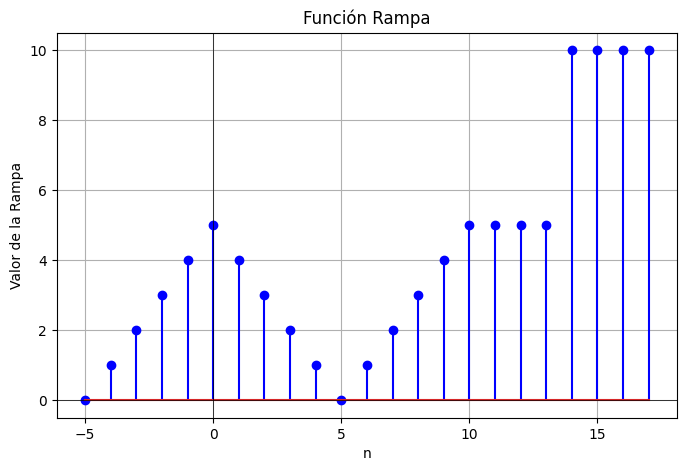

x(n-4): [ 0.  0.  0.  0.  0.  1.  2.  3.  4.  5.  4.  3.  2.  1.  0.  1.  2.  3.
  4.  5.  5.  5.  5. 10. 10. 10. 10.]
x(n): [ 0.  1.  2.  3.  4.  5.  4.  3.  2.  1.  0.  1.  2.  3.  4.  5.  5.  5.
  5. 10. 10. 10. 10.  0.  0.  0.  0.]
x5(n): [ 0.  1.  2.  3.  4.  7.  8.  9. 10. 11.  8.  7.  6.  5.  4.  7.  9. 11.
 13. 20. 20. 20. 20. 20. 20. 20. 20.]


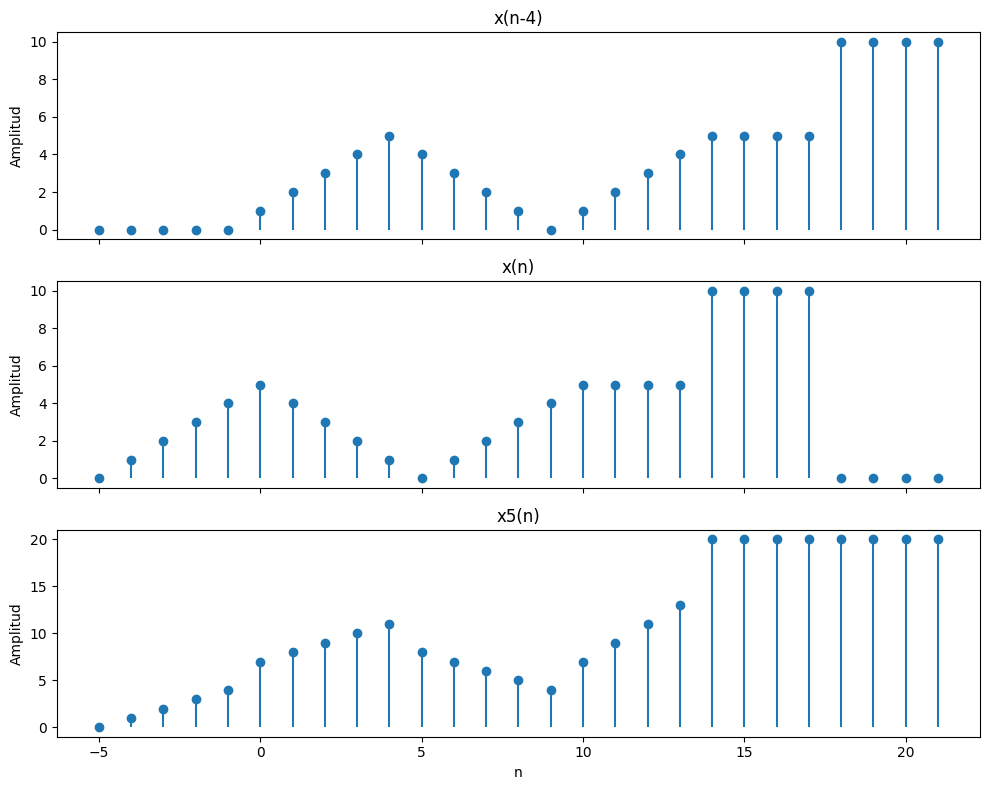

x(n+2): [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  2.  3.  4.
  5.  4.  3.  2.  1.  0.  1.  2.  3.  4.  5.  5.  5.  5. 10. 10. 10. 10.
  0.  0.  0.  0.  0.]
x(n): [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  2.
  3.  4.  5.  4.  3.  2.  1.  0.  1.  2.  3.  4.  5.  5.  5.  5. 10. 10.
 10. 10.  0.  0.  0.]
x6(n): [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -8.09016994e+00 -1.41421356e+01
 -1.76334222e+01 -1.81591737e+01 -1.54497461e+01 -6.25495248e+00
  5.00000000e-03  3.13528419e+00  3.09832479e+00  8.96337814e-03
  5.88524158e+00  1.41421356e+01  2.42905954e+01  3.57064919e+01
  4.77166203e+01  4.97444856e+01  5.07420658e+01  5.06078767e+01
  9.71227956e+01  9.24263606e+01  9.18680310e+01  8.87911023e+01
  2.98095799e+01  4.91476884e+01  0.00000000e+00  0.000000

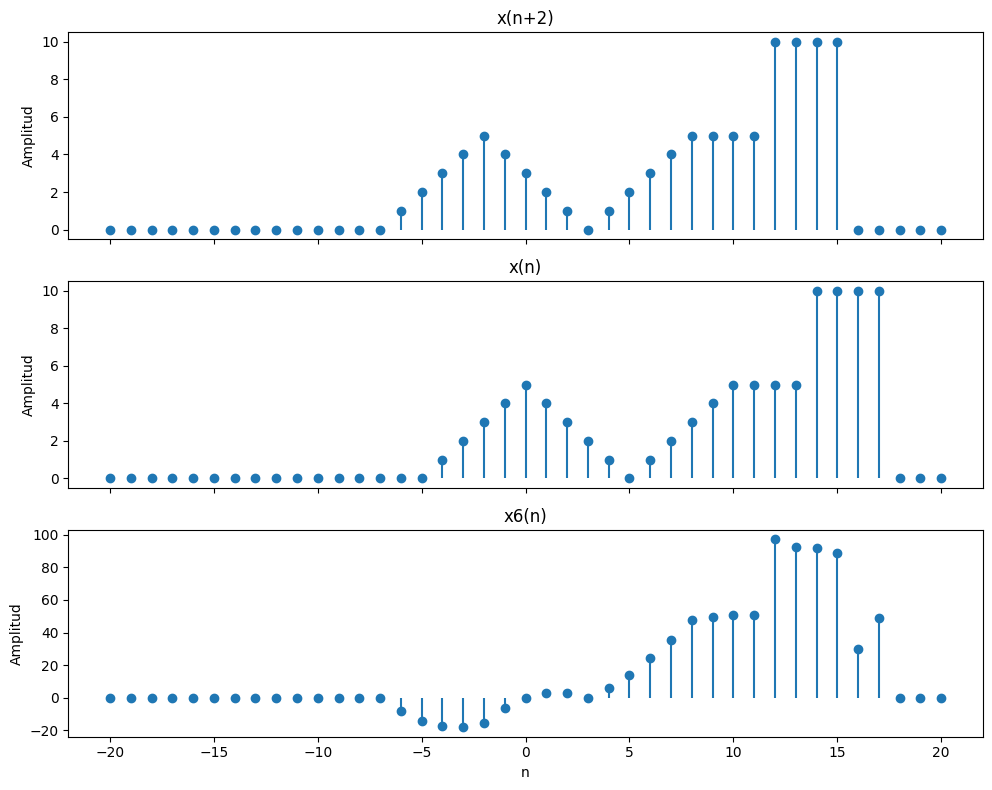

In [36]:
def unitario_(n0, n1, n2):

    n = np.arange(n1, n2+1)
    x = (n - n0) >= 0
    return x, n

def rampa_(n0, n1, n2, m):

  n = np.arange(n1, n2 + 1)
  rampa = np.where(n < n0, 0, np.where(n <= n2, m * (n - n0), m * (n2 - n0)))

  return [rampa,n]

r5a1, n1 = rampa_(-5, -5, 0, 1)

# Segundo tramo: r[n-5] para 6 ≤ n ≤ 11
r5a2, n2 = rampa_(1, 1, 5, -1)

r5a3, n3 = rampa_(6, 6, 10, 1)

u5a1, n4 = unitario_(11, 11, 13)

u5a2, n5 = unitario_(14, 14, 17)

# Concatenar las rampas y los valores de n
x_con = np.concatenate((r5a1, r5a2+4, r5a3+1, 5*u5a1, 10*u5a2))
n_con = np.concatenate((n1, n2, n3, n4, n5))

plt.figure(figsize=(8, 5))
plt.stem(n_con, x_con, 'b')
plt.title('Función Rampa')
plt.xlabel('n')
plt.ylabel('Valor de la Rampa')
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.show()

#x(n-4)
x_shifted1 = np.concatenate([np.zeros(4),x_con])

#definida entre -5 y 21
inf1=-5
sup1=21
n_shifted1=np.arange(inf1,sup1+1)

#x(n) en el nuevo rango
x_shifted2 = np.concatenate([x_con,np.zeros(4)])

f1 = 2*x_shifted1+x_shifted2

print("x(n-4):", x_shifted1)
print("x(n):", x_shifted2)
print("x5(n):", f1)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot para x_shifted1
axs[0].stem(n_shifted1, x_shifted1, basefmt=" ")
axs[0].set_title('x(n-4)')
axs[0].set_ylabel('Amplitud')

# Plot para x_shifted2
axs[1].stem(n_shifted1, x_shifted2, basefmt=" ")
axs[1].set_title('x(n)')
axs[1].set_ylabel('Amplitud')

# Plot para f1
axs[2].stem(n_shifted1, f1, basefmt=" ")
axs[2].set_title('x5(n)')
axs[2].set_xlabel('n')
axs[2].set_ylabel('Amplitud')

# Ajustar el layout para que no haya superposición
plt.tight_layout()

# Mostrar la figura
plt.show()
#x(n+2) definida entre -7 y 15, pero la función en general está definida entre -20 y 20
x_shifted3 = np.concatenate([np.zeros(13),x_con,np.zeros(5)])

#definida entre -20 y 20
inf2=-20
sup2=20
n_shifted2=np.arange(inf2,sup2+1)

#x(n) definida entre -5 y 17 pero la necesitamos en el nuevo rango (-20 a 20)
x_shifted4 = np.concatenate([np.zeros(15),x_con,np.zeros(3)])


f2 = 0.001 * np.exp(0.5 * n_shifted2) * x_shifted4 + 10 * np.sin(0.05 * np.pi * n_shifted2) * x_shifted3

print("x(n+2):", x_shifted3)
print("x(n):", x_shifted4)
print("x6(n):", f2)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot para x_shifted1
axs[0].stem(n_shifted2, x_shifted3, basefmt=" ")
axs[0].set_title('x(n+2)')
axs[0].set_ylabel('Amplitud')

# Plot para x_shifted2
axs[1].stem(n_shifted2, x_shifted4, basefmt=" ")
axs[1].set_title('x(n)')
axs[1].set_ylabel('Amplitud')

# Plot para f1
axs[2].stem(n_shifted2, f2, basefmt=" ")
axs[2].set_title('x6(n)')
axs[2].set_xlabel('n')
axs[2].set_ylabel('Amplitud')

# Ajustar el layout para que no haya superposición
plt.tight_layout()

# Mostrar la figura
plt.show()